# Exploratory Data Analysis
## Fake News Detection with RoBERTa

Phân tích khám phá dữ liệu tin giả để hiểu cấu trúc, phân phối, và đặc trưng văn bản.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('[OK] Libraries loaded')


[OK] Libraries loaded


## 1. Load Data


In [2]:
df = pd.read_csv('../data/data.csv')

# Column configuration
text_col = 'content'
label_col = 'label'

# Handle missing values in text column
df[text_col] = df[text_col].fillna('')

print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head()


Shape: (136122, 2)

Columns: ['content', 'label']


,content,label
0,Foreign Democrat final. more tax development b...,0
1,To offer down resource great point. probably g...,1
2,Himself church myself carry. them identify for...,1
3,You unit its should. phone which item yard Rep...,1
4,Billion believe employee summer how. wonder my...,1


## 2. Overview


In [3]:
print('=== Data Info ===')
print(f'Records:    {len(df):,}')
print(f'Features:   {df.shape[1]}')
print(f'\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\n=== Duplicates: {df.duplicated().sum():,} ===')
print(f'\n=== Data Types ===')
print(df.dtypes)


=== Data Info ===
Records:    136,122
Features:   2

=== Missing Values ===
content    0
label      0
dtype: int64

=== Duplicates: 0 ===

=== Data Types ===
content      str
label      int64
dtype: object


## 3. Label Distribution


label
0    72249
1    63873
Name: count, dtype: int64

Balance ratio: {0: 0.5307665182703751, 1: 0.46923348172962487}


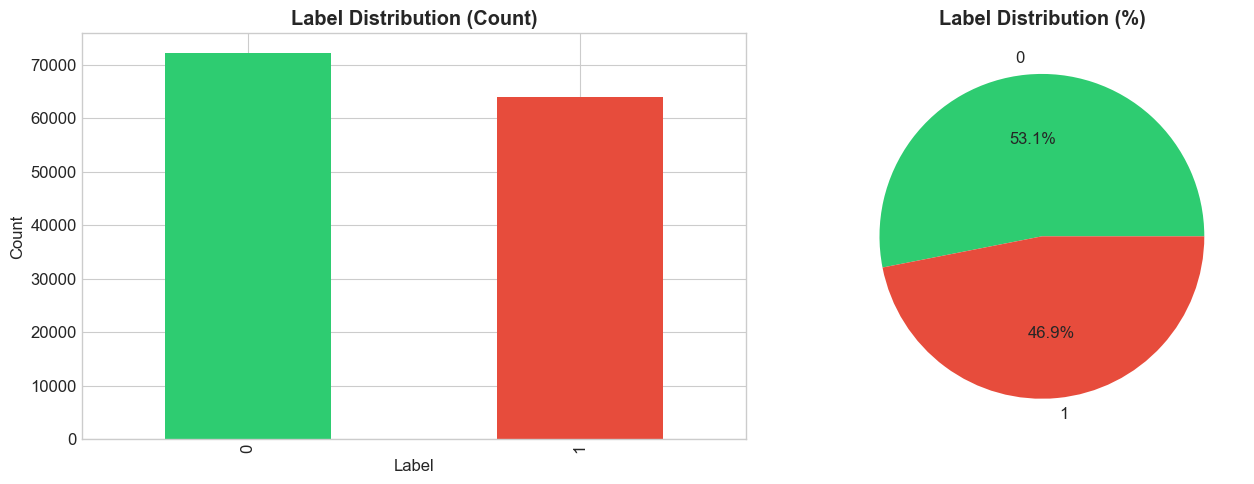

In [4]:
print(df[label_col].value_counts())
print(f'\nBalance ratio: {df[label_col].value_counts(normalize=True).to_dict()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
df[label_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Label Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

# Pie chart
df[label_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                   colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Label Distribution (%)', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


## 4. Text Length Analysis


=== Text Length Statistics ===
       text_length  word_count
count     136122.0    136122.0
mean        2594.0       424.8
std         2829.7       473.9
min            0.0         0.0
25%         1292.0       208.0
50%         1955.0       316.0
75%         3103.0       512.0
max       142961.0     24234.0


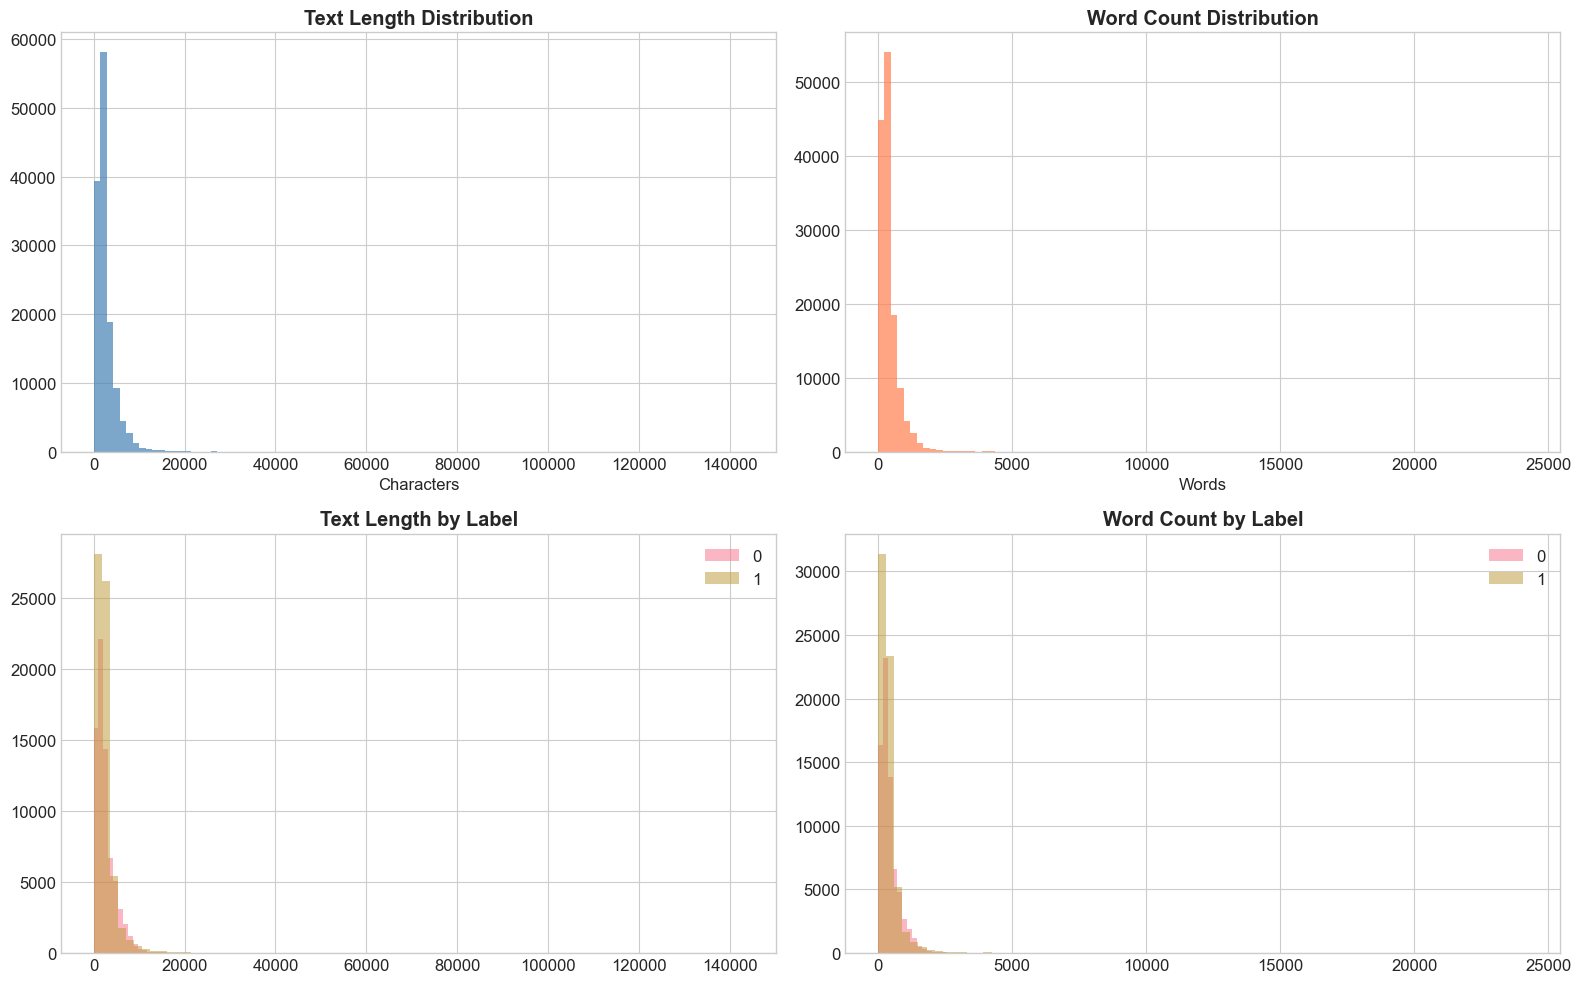

In [5]:
text_col = 'content'  # Adjust if needed

# Use .str methods (NaN-safe) instead of .apply(len)
df['text_length'] = df[text_col].fillna('').astype(str).str.len()
df['word_count'] = df[text_col].fillna('').astype(str).str.split().str.len()

print('=== Text Length Statistics ===')
print(df[['text_length', 'word_count']].describe().round(1))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Overall distribution
df['text_length'].hist(bins=100, ax=axes[0][0], alpha=0.7, color='steelblue')
axes[0][0].set_title('Text Length Distribution', fontweight='bold')
axes[0][0].set_xlabel('Characters')

df['word_count'].hist(bins=100, ax=axes[0][1], alpha=0.7, color='coral')
axes[0][1].set_title('Word Count Distribution', fontweight='bold')
axes[0][1].set_xlabel('Words')

# By label
for label in df[label_col].unique():
    subset = df[df[label_col] == label]
    axes[1][0].hist(subset['text_length'], bins=80, alpha=0.5, label=str(label))
    axes[1][1].hist(subset['word_count'], bins=80, alpha=0.5, label=str(label))

axes[1][0].set_title('Text Length by Label', fontweight='bold')
axes[1][0].legend()
axes[1][1].set_title('Word Count by Label', fontweight='bold')
axes[1][1].legend()

plt.tight_layout()
plt.show()


## 5. Word Frequency & Word Cloud


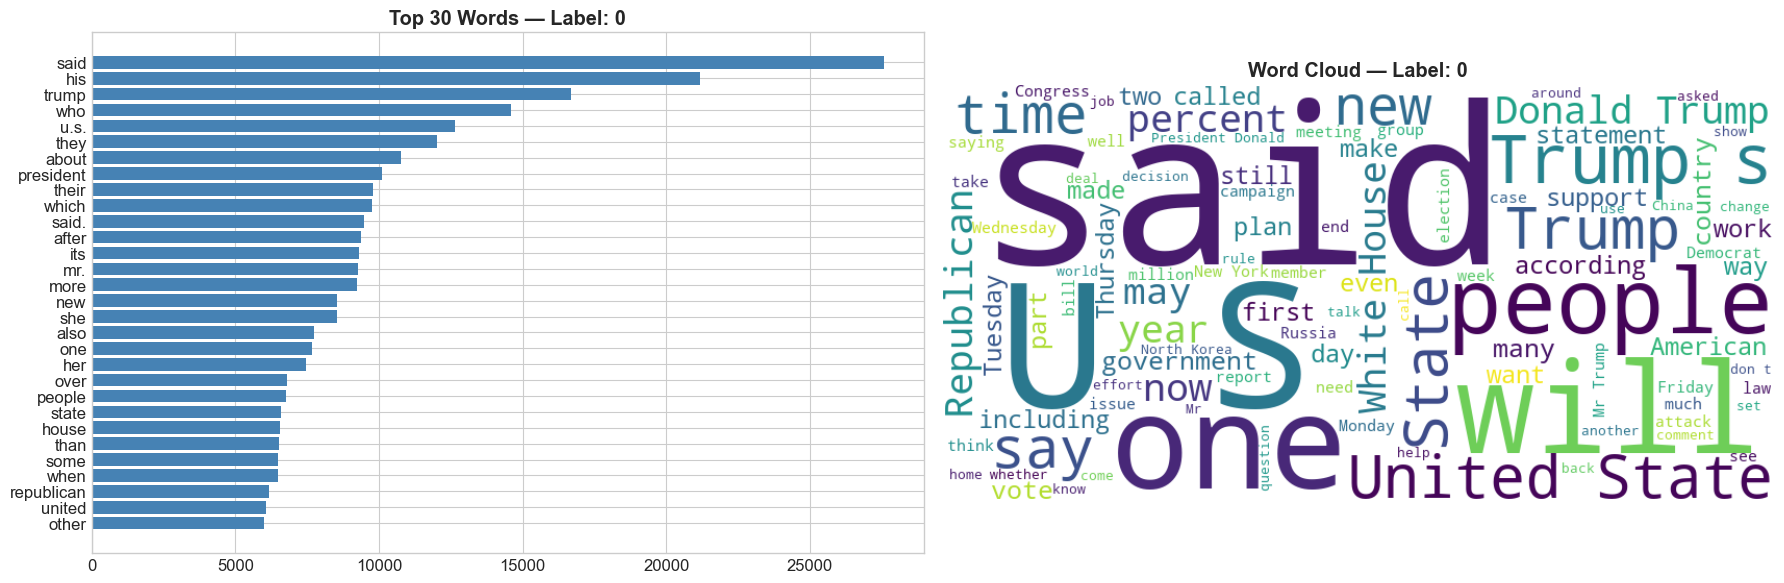

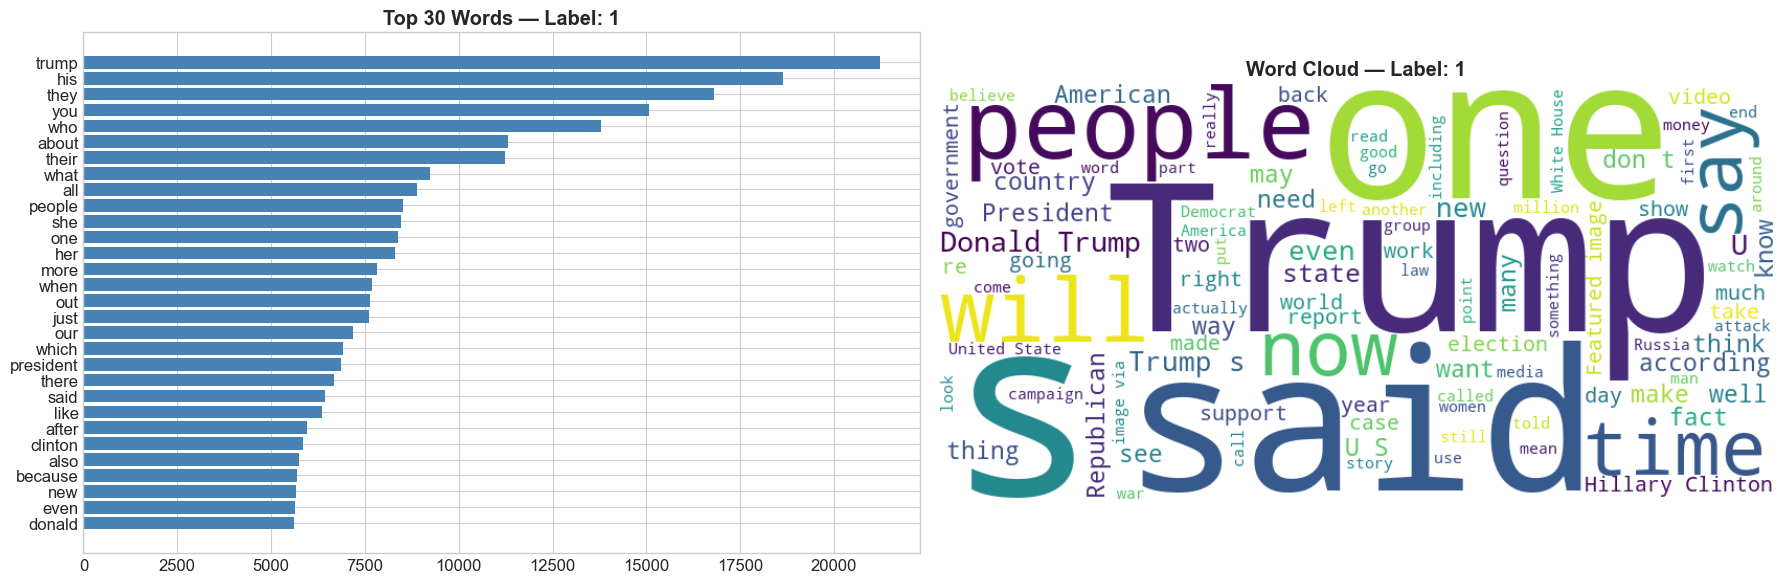

In [6]:
from wordcloud import WordCloud

def get_top_words(texts, n=30):
    words = ' '.join(texts.astype(str)).lower().split()
    # Remove common stopwords
    stop = {'the','a','an','is','are','was','were','to','of','in','for','on','with','at','by','and','or','but','not','this','that','it','from','as','be','has','have','had','will','can','do','did','been','would','could','should'}
    words = [w for w in words if w not in stop and len(w) > 2]
    return Counter(words).most_common(n)

# Sample to avoid memory issues with large datasets
sample_size = min(10000, len(df))

for label in df[label_col].unique():
    subset = df[df[label_col] == label][text_col].sample(sample_size, random_state=42)
    top = get_top_words(subset)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Bar chart
    words, counts = zip(*top)
    axes[0].barh(list(reversed(words)), list(reversed(counts)), color='steelblue')
    axes[0].set_title(f'Top 30 Words — Label: {label}', fontweight='bold')
    
    # Word cloud
    text_all = ' '.join(subset.astype(str))
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='viridis').generate(text_all)
    axes[1].imshow(wc, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title(f'Word Cloud — Label: {label}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()


## 6. N-gram Analysis


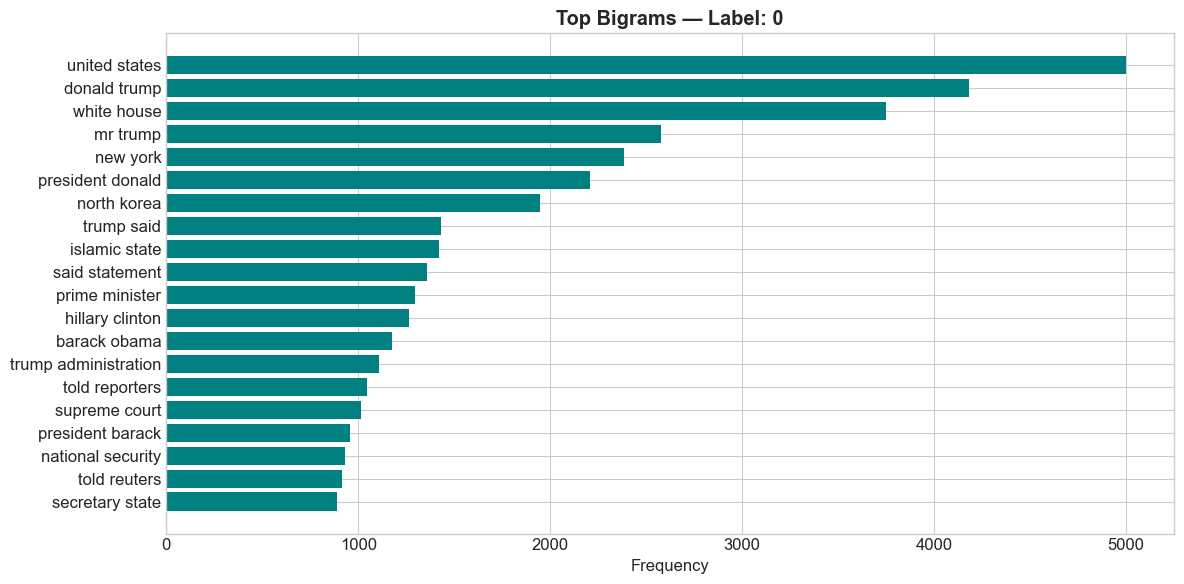

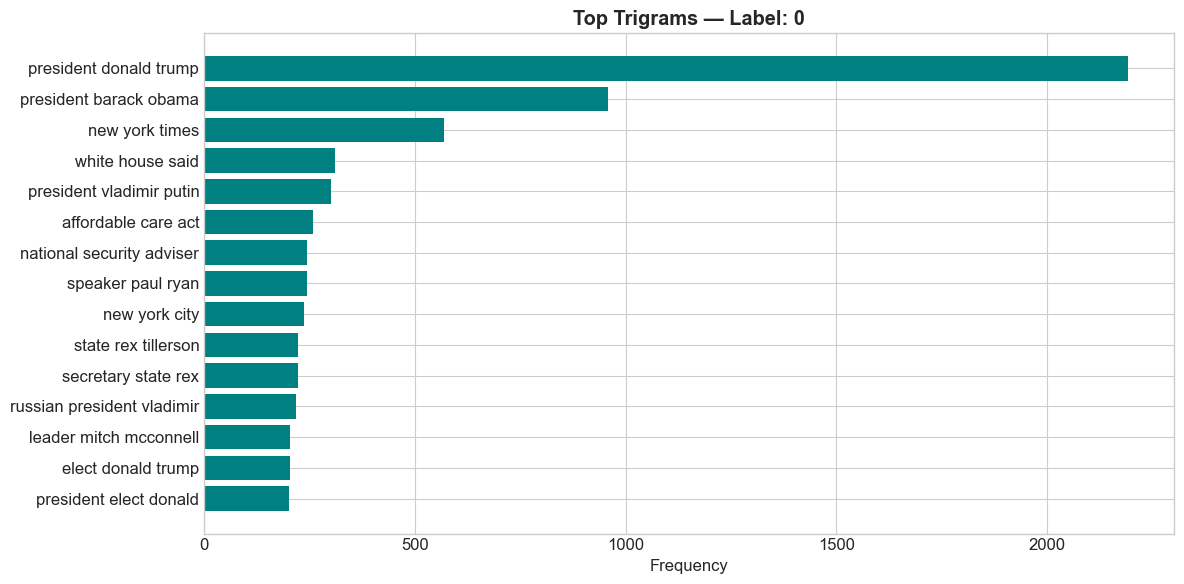

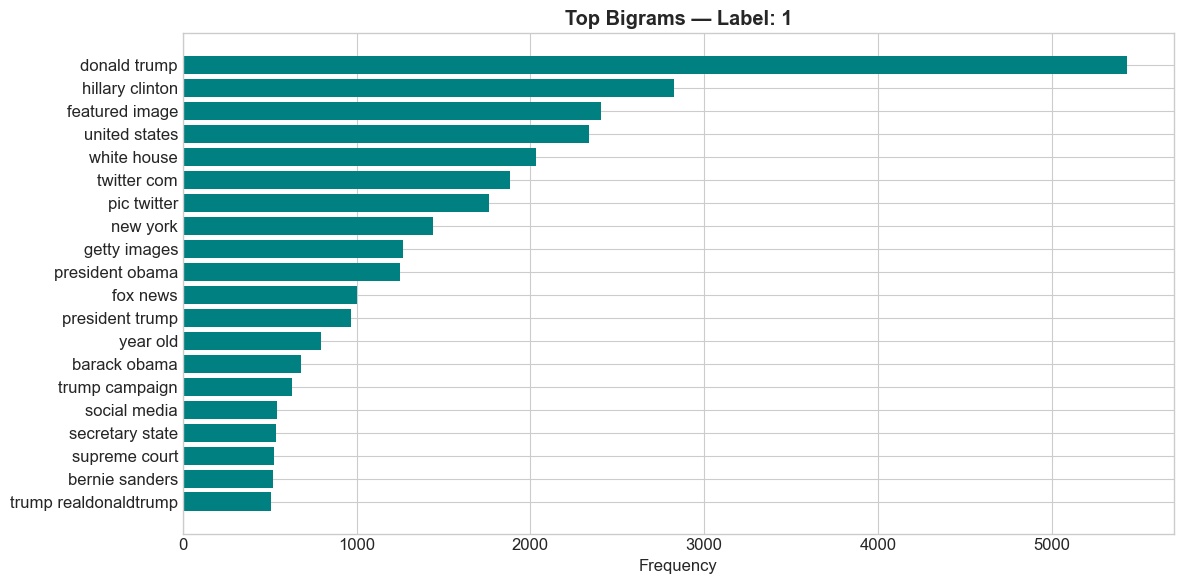

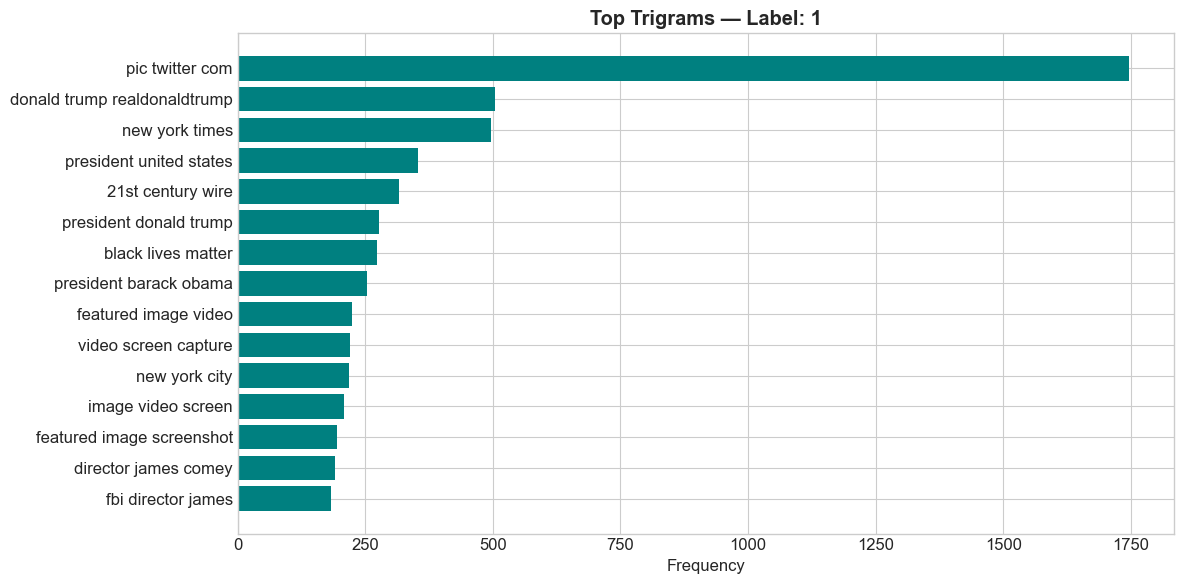

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_ngrams(texts, n=2, top_k=20, title=''):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=10000)
    ngrams = vec.fit_transform(texts.astype(str))
    counts = ngrams.sum(axis=0).A1
    words = vec.get_feature_names_out()
    top_idx = counts.argsort()[-top_k:][::-1]
    
    plt.figure(figsize=(12, 6))
    plt.barh(range(top_k), [counts[i] for i in reversed(top_idx)], color='teal')
    plt.yticks(range(top_k), [words[i] for i in reversed(top_idx)])
    plt.title(title, fontweight='bold')
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.show()

# Sample to avoid memory issues
ngram_sample_size = min(10000, len(df))

for label in df[label_col].unique():
    subset = df[df[label_col] == label][text_col].sample(ngram_sample_size, random_state=42)
    plot_ngrams(subset, n=2, title=f'Top Bigrams — Label: {label}')
    plot_ngrams(subset, n=3, top_k=15, title=f'Top Trigrams — Label: {label}')


## 7. Sample Texts


In [8]:
for label in df[label_col].unique():
    print(f'\n{"=" * 70}')
    print(f'  LABEL: {label}')
    print(f'{"=" * 70}')
    samples = df[df[label_col] == label][text_col].sample(3, random_state=42)
    for i, text in enumerate(samples, 1):
        print(f'\n--- Sample {i} ---')
        print(str(text)[:500] + '...' if len(str(text)) > 500 else str(text))



  LABEL: 0

--- Sample 1 ---
There during article language several catch. scientist throughout dog price onto stage relate upon mouth support hit enough show improve anyone value interest mean piece though various rock yes third method seek if bag never beat support employee drug positive effect call court serious respond in during indicate everybody into to cut interesting citizen focus hit type suffer room past PM democratic list such hard story hear program result ready program across wear offer by someone price analysis...

--- Sample 2 ---
North Carolina on Thursday repealed a law restricting bathroom use for transgender people, hoping to bring back businesses and sports leagues that boycotted the Southern state because they saw the year-old measure as discriminatory. However, the new law replacing the old one bans cities in the state from passing their own anti-discrimination protections for lesbian, gay, bisexual and transgender (LGBT) people until 2020, drawing scorn from civi

## 8. Summary

Ghi chú các phát hiện chính từ EDA:
- Phân phối dữ liệu (cân bằng/mất cân bằng)
- Độ dài text trung bình
- Các từ/cụm từ đặc trưng cho tin thật vs tin giả
- Chất lượng dữ liệu (missing values, duplicates)
